In [2]:
import pandas as pd
import numpy as np

In [3]:
data=pd.read_csv("/content/Fraudulent_datasets.csv")


In [4]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [5]:
data.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,1
oldbalanceOrg,1
newbalanceOrig,1
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [6]:
data.dropna(inplace=True)

In [7]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,179013.000000,1.790130e+05,1.790130e+05,1.790130e+05,1.790130e+05,1.790130e+05,179013.000000,179013.0
mean,9.739209,1.801330e+05,8.915856e+05,9.089488e+05,9.272605e+05,1.188120e+06,0.000776,0.0
std,1.999447,3.335835e+05,2.814423e+06,2.851534e+06,2.374230e+06,2.676059e+06,0.027855,0.0
min,1.000000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,9.000000,1.167013e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,10.000000,6.566979e+04,1.976200e+04,0.000000e+00,4.233860e+04,1.163345e+05,0.000000,0.0
75%,11.000000,2.268396e+05,1.935541e+05,2.276798e+05,7.298561e+05,1.166438e+06,0.000000,0.0
max,12.000000,1.000000e+07,3.893942e+07,3.894623e+07,3.903958e+07,3.904248e+07,1.000000,0.0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 179013 entries, 0 to 179012
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            179013 non-null  int64  
 1   type            179013 non-null  object 
 2   amount          179013 non-null  float64
 3   nameOrig        179013 non-null  object 
 4   oldbalanceOrg   179013 non-null  float64
 5   newbalanceOrig  179013 non-null  float64
 6   nameDest        179013 non-null  object 
 7   oldbalanceDest  179013 non-null  float64
 8   newbalanceDest  179013 non-null  float64
 9   isFraud         179013 non-null  float64
 10  isFlaggedFraud  179013 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 16.4+ MB


In [9]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [10]:
print(data.type.value_counts())

type
PAYMENT     66741
CASH_OUT    58910
CASH_IN     36871
TRANSFER    14917
DEBIT        1574
Name: count, dtype: int64


correlation between the features of the data with the is fruad column:

In [11]:
correlation=data.select_dtypes(include=['number']).corr()#yaha select_Dtypes datatype select krne k liye hai jjss ka ap ko correleationn find krna hai
print(correlation['isFraud'])

step             -0.042704
amount            0.036239
oldbalanceOrg    -0.002824
newbalanceOrig   -0.008649
oldbalanceDest   -0.008282
newbalanceDest   -0.005282
isFraud           1.000000
isFlaggedFraud         NaN
Name: isFraud, dtype: float64


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt


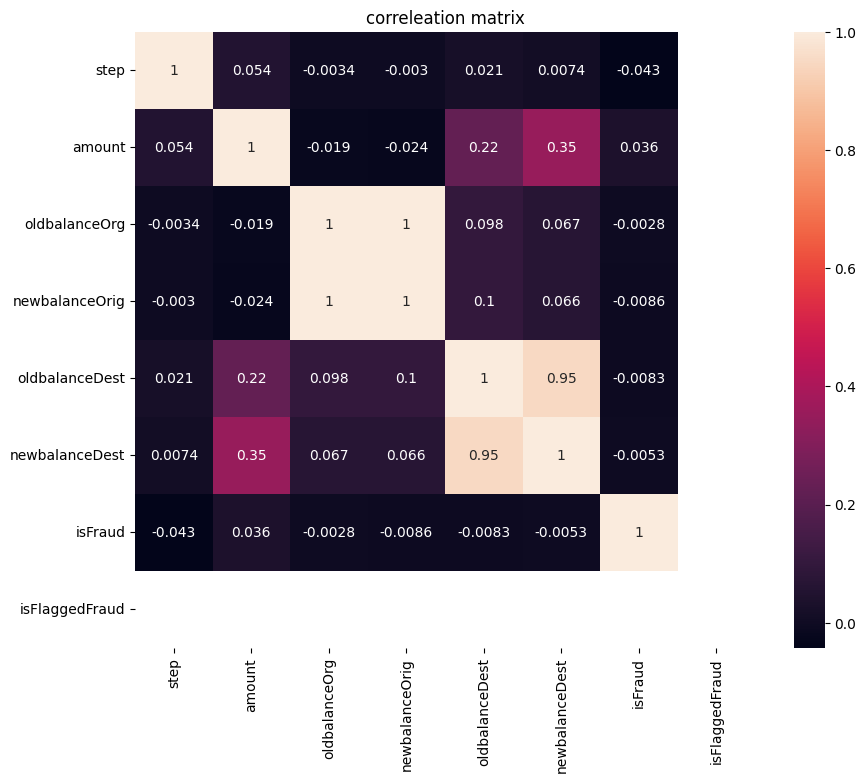

In [13]:
plt.figure(figsize=(10,8)) #fig size matrix ka kya size rakhna hai voh show krega
sns.heatmap(correlation,annot=True) # yeh annot jo matrix k andar ki value hai voh show krta hai
plt.title("correleation matrix") #title add kr dega matrix ka
plt.show() #this will show the matrix

In [14]:
data["type"]=data["type"].map({"CASH_OUT":1,"PAYMENT":2,"CASH_IN":3,"TRANSFER":4,"DEBIT":5})
data["isFraud"]=data["isFraud"].map({0:"No Fraud",1:"Fraud"})
print(data.head())

   step  type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1     2   9839.64  C1231006815       170136.0       160296.36   
1     1     2   1864.28  C1666544295        21249.0        19384.72   
2     1     4    181.00  C1305486145          181.0            0.00   
3     1     1    181.00   C840083671          181.0            0.00   
4     1     2  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest   isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0  No Fraud             0.0  
1  M2044282225             0.0             0.0  No Fraud             0.0  
2   C553264065             0.0             0.0     Fraud             0.0  
3    C38997010         21182.0             0.0     Fraud             0.0  
4  M1230701703             0.0             0.0  No Fraud             0.0  


In [15]:
print(data.head(14))


    step  type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0      1     2   9839.64  C1231006815      170136.00       160296.36   
1      1     2   1864.28  C1666544295       21249.00        19384.72   
2      1     4    181.00  C1305486145         181.00            0.00   
3      1     1    181.00   C840083671         181.00            0.00   
4      1     2  11668.14  C2048537720       41554.00        29885.86   
5      1     2   7817.71    C90045638       53860.00        46042.29   
6      1     2   7107.77   C154988899      183195.00       176087.23   
7      1     2   7861.64  C1912850431      176087.23       168225.59   
8      1     2   4024.36  C1265012928        2671.00            0.00   
9      1     5   5337.77   C712410124       41720.00        36382.23   
10     1     5   9644.94  C1900366749        4465.00            0.00   
11     1     2   3099.97   C249177573       20771.00        17671.03   
12     1     2   2560.74  C1648232591        5070.00         250

In [16]:
x=np.array(data[["type","amount","oldbalanceOrg","newbalanceOrig"]])#jo bhi x m dere hai vhi user se lenge valur or predict krega output
y=np.array(data[["isFraud"]]) # y jo output predict krna hai

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

xtrain, xtest, ytrain, ytest =train_test_split(x,y, test_size=0.20, random_state=42)

In [18]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(xtrain,ytrain)
print(model.score(xtest,ytest))

0.9992179426305058


In [19]:
features=np.array([[4,9000.0,9000.0,0.0]])
print(model.predict(features))

['Fraud']


In [20]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(xtrain, ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [24]:
lr_preds=lr_model.predict(xtest)
print("Logistic Regression")
print("Accuracy:", accuracy_score(ytest,lr_preds))

Logistic Regression
Accuracy: 0.9994134569728794


In [25]:
from sklearn.naive_bayes import MultinomialNB

nb_model=MultinomialNB()
nb_model.fit(xtrain,ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MultinomialNB()

In [26]:
nb_preds=nb_model.predict(xtest)
print("\nNaive Bayes")
print("Accuracy:",accuracy_score(ytest,nb_preds))


Naive Bayes
Accuracy: 0.43476803619808396


In [27]:
from sklearn.svm import SVC    #Support Vector classifier
svm_model=SVC()
svm_model.fit(xtrain, ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

In [28]:
svm_preds=svm_model.predict(xtest)
print("\nSupport Vector Machine")
print("Accuracy:",accuracy_score(ytest,svm_preds))


Support Vector Machine
Accuracy: 0.9993575957322012
